Fetching data...


/tmp/ipython-input-153/3121380072.py:13: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(tickers, start=start_date)['Close'].dropna()
[*********************100%***********************]  2 of 2 completed


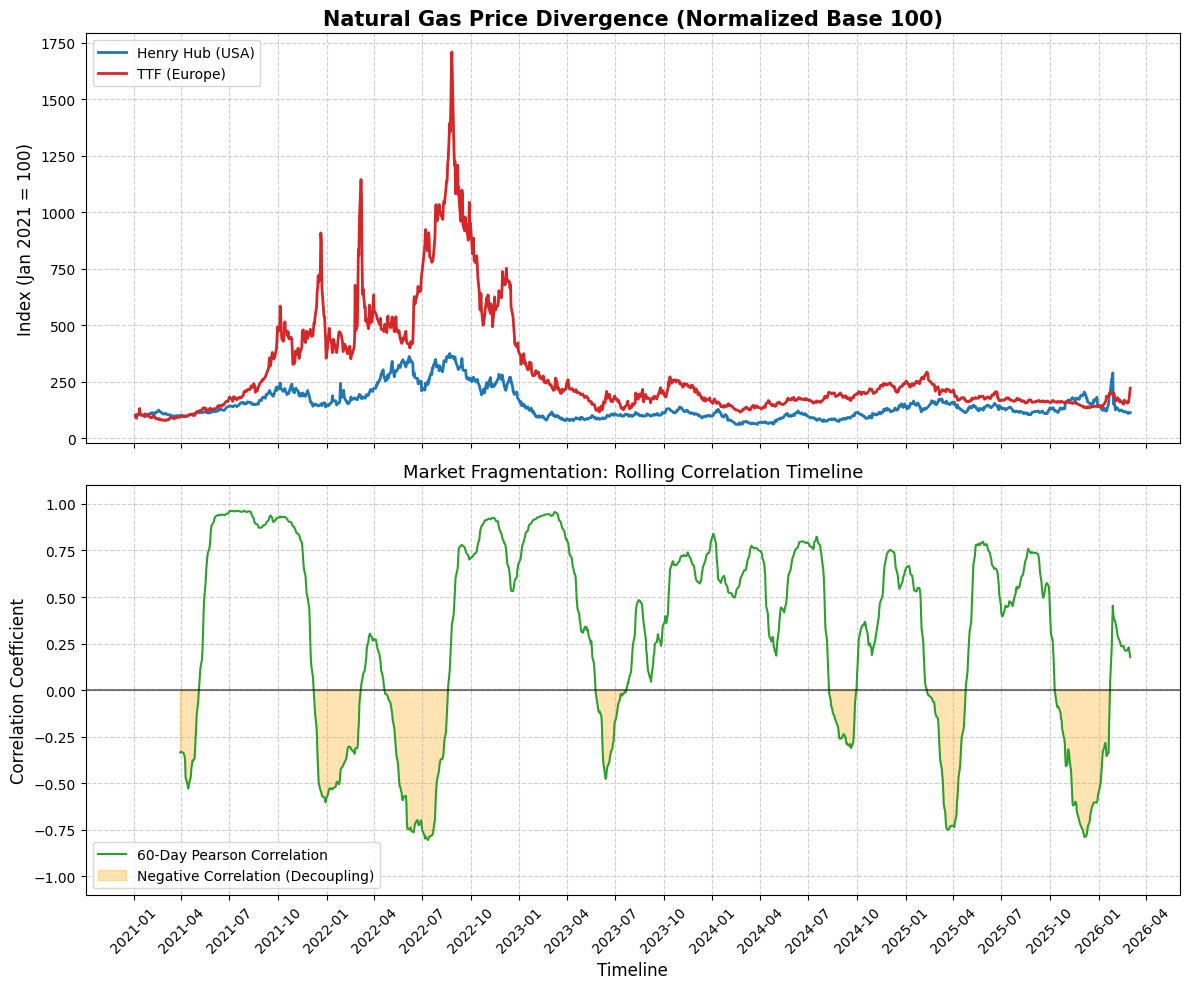

In [3]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# 1. Configuration & Data Fetching
# NG=F: Henry Hub (USA) | TTF=F: Dutch TTF (Europe)
tickers = ["NG=F", "TTF=F"]

def analyze_gas_markets(start_date="2021-01-01"):
    print("Fetching data...")
    # Using 'Close' to avoid the KeyError: 'Adj Close'
    data = yf.download(tickers, start=start_date)['Close'].dropna()

    # 2. Mathematical Normalization (Base 100)
    # This allows us to compare growth rates despite different units ($/MMBtu vs €/MWh)
    df_norm = (data / data.iloc[0]) * 100

    # 3. Statistical Analysis: 60-Day Rolling Correlation
    # Pearson correlation coefficient captures the linear relationship over time
    rolling_corr = data['NG=F'].rolling(window=60).corr(data['TTF=F'])

    # 4. Visualization
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10), sharex=True)

    # --- Top Plot: Prices ---
    ax1.plot(df_norm.index, df_norm['NG=F'], label='Henry Hub (USA)', color='#1f77b4', lw=2)
    ax1.plot(df_norm.index, df_norm['TTF=F'], label='TTF (Europe)', color='#d62728', lw=2)

    ax1.set_title('Natural Gas Price Divergence (Normalized Base 100)', fontsize=15, fontweight='bold')
    ax1.set_ylabel('Index (Jan 2021 = 100)', fontsize=12)
    ax1.legend(loc='upper left')
    ax1.grid(True, linestyle='--', alpha=0.6)

    # --- Bottom Plot: Rolling Correlation ---
    ax2.plot(rolling_corr.index, rolling_corr, color='#2ca02c', label='60-Day Pearson Correlation')
    ax2.axhline(y=0, color='black', linestyle='-', alpha=0.5)

    # Highlight negative correlation areas (Market Fragmentation)
    ax2.fill_between(rolling_corr.index, rolling_corr, 0,
                     where=(rolling_corr < 0), color='orange', alpha=0.3,
                     label='Negative Correlation (Decoupling)')

    ax2.set_title('Market Fragmentation: Rolling Correlation Timeline', fontsize=13)
    ax2.set_ylabel('Correlation Coefficient', fontsize=12)
    ax2.set_xlabel('Timeline', fontsize=12)
    ax2.set_ylim(-1.1, 1.1)
    ax2.legend(loc='lower left')
    ax2.grid(True, linestyle='--', alpha=0.6)

    # --- X-Axis (Timeline) Formatting ---
    ax2.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
    ax2.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
    plt.xticks(rotation=45)

    plt.tight_layout()
    plt.show()

    # Optional: Save for further analysis
    # data.to_csv('gas_market_data.csv')

if __name__ == "__main__":
    analyze_gas_markets()

/tmp/ipython-input-153/2749656482.py:7: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(tickers, start="2021-01-01")['Close'].dropna()
[*********************100%***********************]  3 of 3 completed


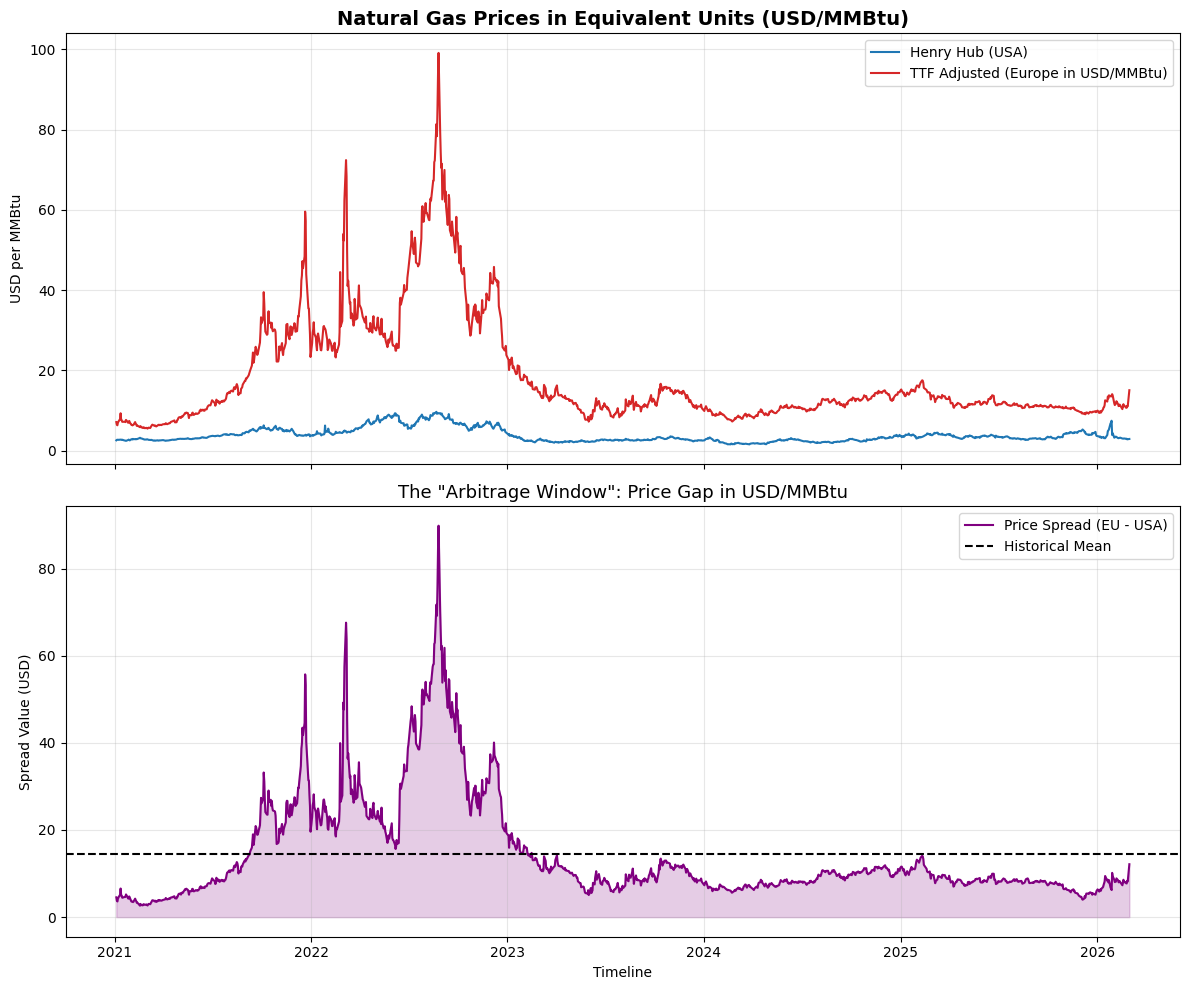

In [4]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt

# 1. Download dati: Gas USA, Gas Europa e Cambio Euro/Dollaro
tickers = ["NG=F", "TTF=F", "EURUSD=X"]
data = yf.download(tickers, start="2021-01-01")['Close'].dropna()

# 2. Calcolo dello Spread in USD/MMBtu
# Formula: (TTF_in_Euro / 3.412) * EURUSD
data['TTF_USD_MMBTU'] = (data['TTF=F'] / 3.412) * data['EURUSD=X']
data['Spread'] = data['TTF_USD_MMBTU'] - data['NG=F']

# 3. Visualizzazione
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10), sharex=True)

# Grafico 1: Prezzi comparabili in USD/MMBtu
ax1.plot(data.index, data['NG=F'], label='Henry Hub (USA)', color='#1f77b4')
ax1.plot(data.index, data['TTF_USD_MMBTU'], label='TTF Adjusted (Europe in USD/MMBtu)', color='#d62728')
ax1.set_title('Natural Gas Prices in Equivalent Units (USD/MMBtu)', fontsize=14, fontweight='bold')
ax1.set_ylabel('USD per MMBtu')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Grafico 2: Lo Spread (TTF - Henry Hub)
ax2.fill_between(data.index, data['Spread'], color='purple', alpha=0.2)
ax2.plot(data.index, data['Spread'], color='purple', label='Price Spread (EU - USA)')
ax2.axhline(y=data['Spread'].mean(), color='black', linestyle='--', label='Historical Mean')
ax2.set_title('The "Arbitrage Window": Price Gap in USD/MMBtu', fontsize=13)
ax2.set_ylabel('Spread Value (USD)')
ax2.set_xlabel('Timeline')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

/tmp/ipython-input-153/3665755109.py:12: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(tickers, start=start_date_fetch)['Close'].dropna()
[*********************100%***********************]  3 of 3 completed


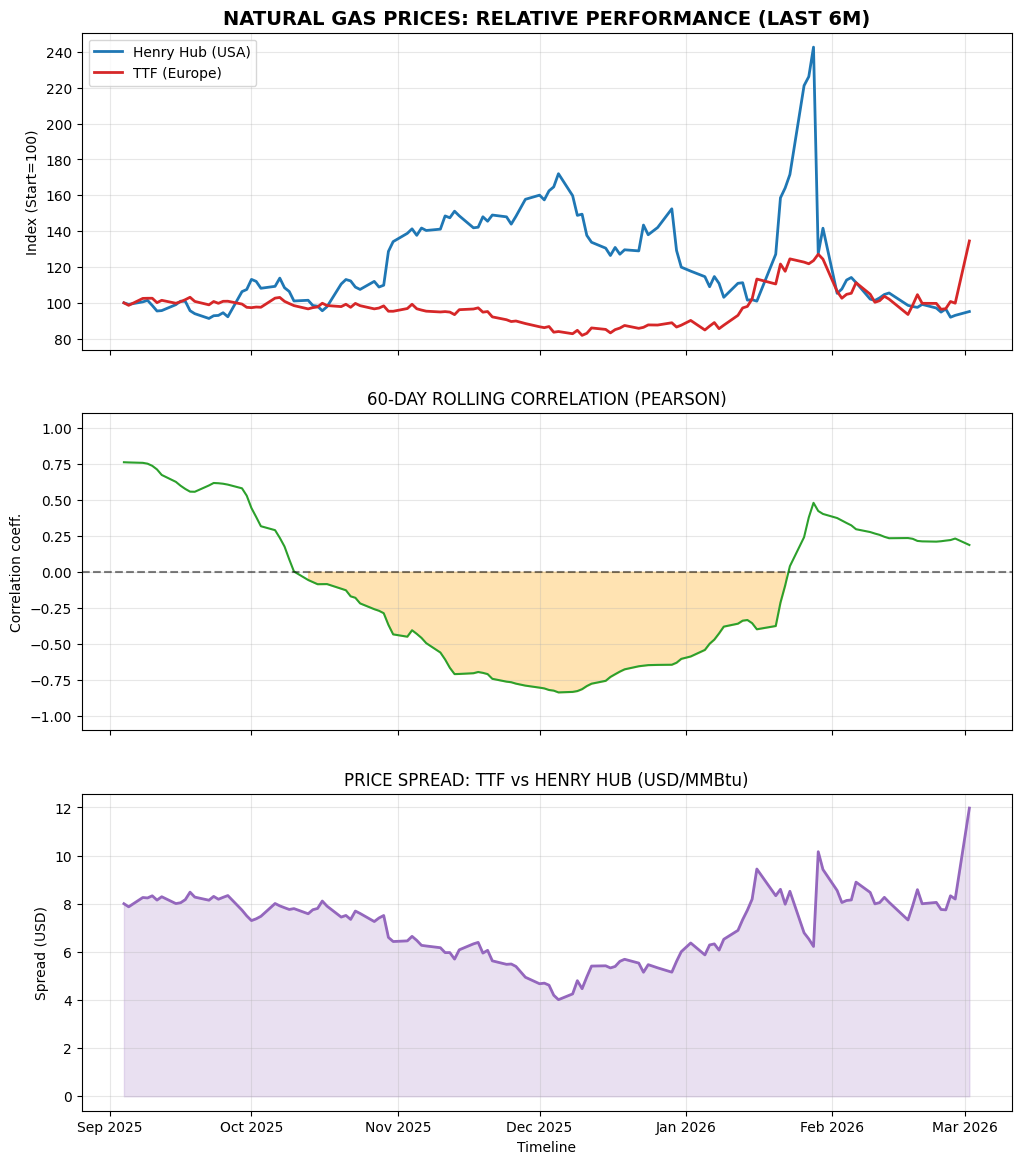

In [13]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from datetime import datetime, timedelta

# 1. Settings & Data Fetching
# NG=F: Henry Hub | TTF=F: Dutch TTF | EURUSD=X: Exchange Rate
tickers = ["NG=F", "TTF=F", "EURUSD=X"]
end_date = datetime.now()
start_date_fetch = end_date - timedelta(days=365) # Fetch 1yr for rolling stats
data = yf.download(tickers, start=start_date_fetch)['Close'].dropna()

# 2. Data Processing
# Convert TTF to USD/MMBtu: (EUR/MWh / 3.412) * EURUSD
data['TTF_USD'] = (data['TTF=F'] / 3.412) * data['EURUSD=X']

# Normalized Prices (Base 100 at the start of the 6-month window)
last_6m_start = end_date - timedelta(days=180)
df_zoom = data[data.index >= last_6m_start].copy()
df_norm = (df_zoom[['NG=F', 'TTF_USD']] / df_zoom[['NG=F', 'TTF_USD']].iloc[0]) * 100

# Rolling Correlation (Calculated on full data then sliced)
data['Correlation'] = data['NG=F'].rolling(60).corr(data['TTF_USD'])
corr_zoom = data[data.index >= last_6m_start]['Correlation']

# Spread Calculation
df_zoom['Spread'] = df_zoom['TTF_USD'] - df_zoom['NG=F']

# 3. Plotting Dashboard
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(12, 14), sharex=True)
plt.subplots_adjust(hspace=0.2)

# Subplot 1: Normalized Prices
ax1.plot(df_norm.index, df_norm['NG=F'], label='Henry Hub (USA)', color='#1f77b4', lw=2)
ax1.plot(df_norm.index, df_norm['TTF_USD'], label='TTF (Europe)', color='#d62728', lw=2)
ax1.set_title('NATURAL GAS PRICES: RELATIVE PERFORMANCE (LAST 6M)', fontsize=14, fontweight='bold')
ax1.set_ylabel('Index (Start=100)')
ax1.legend(loc='upper left')
ax1.grid(True, alpha=0.3)

# Subplot 2: Rolling Correlation
ax2.plot(corr_zoom.index, corr_zoom, color='#2ca02c', lw=1.5)
ax2.axhline(y=0, color='black', linestyle='--', alpha=0.5)
ax2.fill_between(corr_zoom.index, corr_zoom, 0, where=(corr_zoom < 0), color='orange', alpha=0.3, label='Inverse Correlation')
ax2.set_title('60-DAY ROLLING CORRELATION (PEARSON)', fontsize=12)
ax2.set_ylabel('Correlation coeff.')
ax2.set_ylim(-1.1, 1.1)
ax2.grid(True, alpha=0.3)

# Subplot 3: Price Spread (The Arbitrage Gap)
ax3.fill_between(df_zoom.index, df_zoom['Spread'], color='#9467bd', alpha=0.2)
ax3.plot(df_zoom.index, df_zoom['Spread'], color='#9467bd', lw=2)
ax3.set_title('PRICE SPREAD: TTF vs HENRY HUB (USD/MMBtu)', fontsize=12)
ax3.set_ylabel('Spread (USD)')
ax3.set_xlabel('Timeline')
ax3.grid(True, alpha=0.3)

# X-Axis Formatting
ax3.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.xticks(rotation=0)

plt.show()

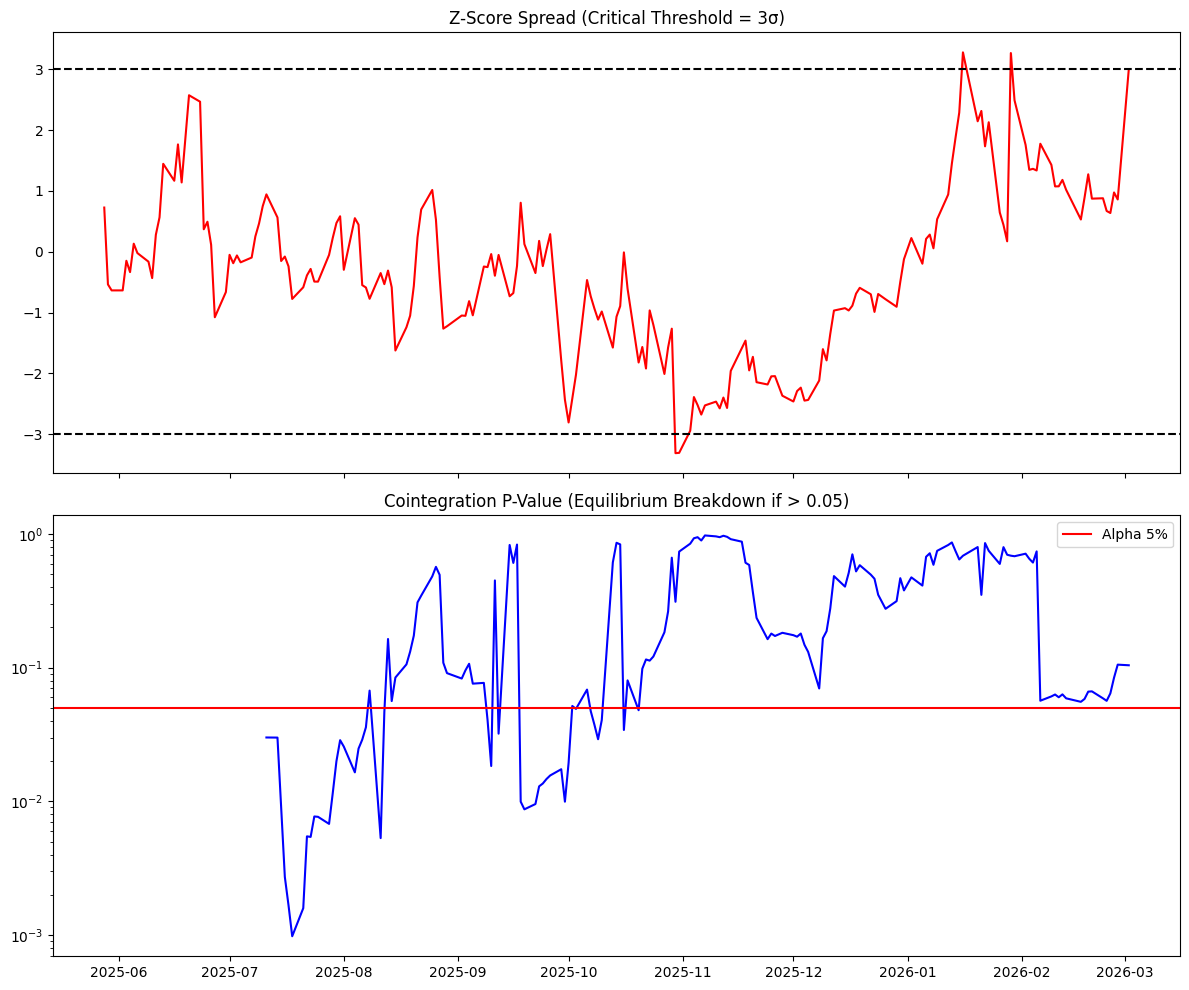

In [14]:
import numpy as np
import pandas as pd
import yfinance as yf
import statsmodels.api as sm
from statsmodels.tsa.stattools import coint

# 1. Preparazione dati (Assumiamo di avere 'data' con TTF_USD e NG=F)
# ... (download come nei post precedenti) ...

# 2. Calcolo dello Z-Score dello Spread (Finestra 60gg)
window = 60
data['Spread'] = data['TTF_USD'] - data['NG=F']
data['Mean_Spread'] = data['Spread'].rolling(window=window).mean()
data['Std_Spread'] = data['Spread'].rolling(window=window).std()
data['Z_Score'] = (data['Spread'] - data['Mean_Spread']) / data['Std_Spread']

# 3. Rolling Cointegration Test (P-Value)
# Questo è l'indicatore della "salute" del legame matematico
def get_coint_pvalue(x, y):
    # Ritorna il p-value del test di cointegrazione di Engel-Granger
    _, p_val, _ = coint(x, y)
    return p_val

# Calcoliamo il p-value su una finestra mobile (es. 90 giorni)
data['Coint_PValue'] = [np.nan] * len(data)
for i in range(90, len(data)):
    slice_hh = data['NG=F'].iloc[i-90:i]
    slice_ttf = data['TTF_USD'].iloc[i-90:i]
    data.iloc[i, data.columns.get_loc('Coint_PValue')] = get_coint_pvalue(slice_hh, slice_ttf)

# 4. Plot Diagnostico
import matplotlib.pyplot as plt
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10), sharex=True)

# AX 1: Lo Z-Score (Se > 3, l'equilibrio è rotto)
ax1.plot(data.index, data['Z_Score'], color='red')
ax1.axhline(3, color='black', linestyle='--')
ax1.axhline(-3, color='black', linestyle='--')
ax1.fill_between(data.index, 3, data['Z_Score'], where=(data['Z_Score'] > 3), color='red', alpha=0.3)
ax1.set_title('Z-Score Spread (Critical Threshold = 3σ)')

# AX 2: P-Value Cointegrazione (Se > 0.05, non c'è più legame logico)
ax2.plot(data.index, data['Coint_PValue'], color='blue')
ax2.axhline(0.05, color='red', linestyle='-', label='Alpha 5%')
ax2.set_title('Cointegration P-Value (Equilibrium Breakdown if > 0.05)')
ax2.set_yscale('log') # Utile per vedere le variazioni di ordini di grandezza
ax2.legend()

plt.tight_layout()
plt.show()

/tmp/ipython-input-153/549548619.py:9: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(tickers, start="2021-01-01")['Close'].dropna()
[*********************100%***********************]  3 of 3 completed


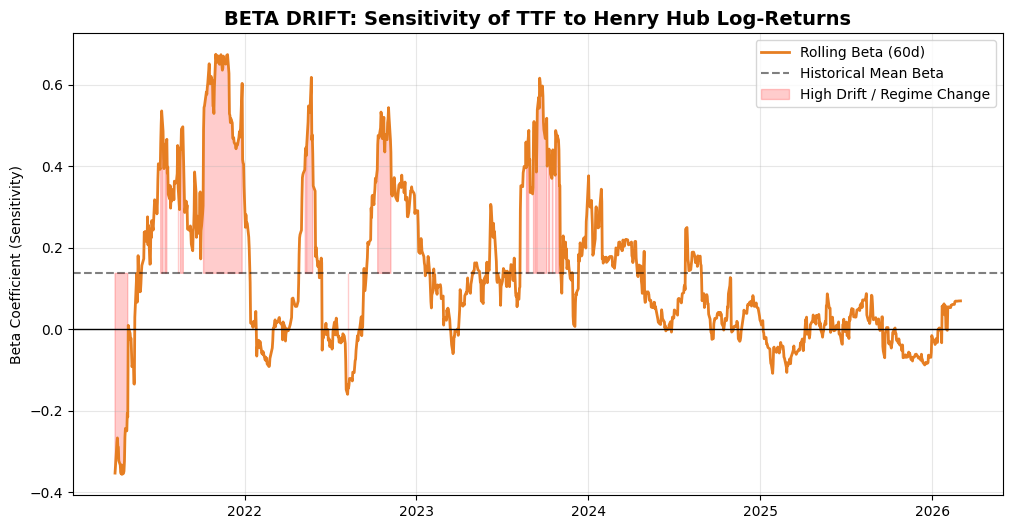

In [11]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

# 1. Fetching Data
tickers = ["NG=F", "TTF=F", "EURUSD=X"]
data = yf.download(tickers, start="2021-01-01")['Close'].dropna()
data['TTF_USD'] = (data['TTF=F'] / 3.412) * data['EURUSD=X']

# 2. Calculating Returns (Log Returns are better for Beta analysis)
data['Ret_HH'] = np.log(data['NG=F'] / data['NG=F'].shift(1))
data['Ret_TTF'] = np.log(data['TTF_USD'] / data['TTF_USD'].shift(1))
data = data.dropna()

# 3. Rolling Beta Calculation (Window: 60 days)
window = 60
betas = []
dates = []

for i in range(window, len(data)):
    # Slice the data
    y = data['Ret_TTF'].iloc[i-window:i].values.reshape(-1, 1) # Dependent
    X = data['Ret_HH'].iloc[i-window:i].values.reshape(-1, 1)  # Independent

    # Fit Linear Regression
    model = LinearRegression().fit(X, y)
    betas.append(model.coef_[0][0])
    dates.append(data.index[i])

beta_series = pd.Series(betas, index=dates)

# 4. Visualization of Beta Drift
plt.figure(figsize=(12, 6))
plt.plot(beta_series.index, beta_series, color='#e67e22', lw=2, label='Rolling Beta (60d)')
plt.axhline(y=beta_series.mean(), color='black', linestyle='--', alpha=0.5, label='Historical Mean Beta')
plt.axhline(y=0, color='black', lw=1)

# Highlight Drift Zones (where Beta diverges significantly from mean)
plt.fill_between(beta_series.index, beta_series, beta_series.mean(),
                 where=(np.abs(beta_series - beta_series.mean()) > beta_series.std()*1.5),
                 color='red', alpha=0.2, label='High Drift / Regime Change')

plt.title('BETA DRIFT: Sensitivity of TTF to Henry Hub Log-Returns', fontsize=14, fontweight='bold')
plt.ylabel('Beta Coefficient (Sensitivity)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()